In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import xarray as xr


In [ ]:
#shape area 
shape_area_manning = 6642 * 1e6  # m²

#evap
evap_daily = pd.read_csv("./Data/manning_ERA5_evap_daily.csv")
evap_daily['Date'] = pd.to_datetime(evap_daily['system:index'], format='%Y%m%d')
evap_daily = evap_daily.set_index('Date')[['total_evaporation_sum']]
evap_daily = evap_daily.rename(columns={'total_evaporation_sum': 'ERA5_Evaporation'})
# m/day to mm/day 
evap_daily['ERA5_Evaporation'] = evap_daily['ERA5_Evaporation'].abs() * 1000

#precip
precip_daily = pd.read_csv("./Data/manning_ERA5_precip_daily.csv")
precip_daily['Date'] = pd.to_datetime(precip_daily['system:index'], format='%Y%m%d')
precip_daily = precip_daily.set_index('Date')[['total_precipitation_sum']]
precip_daily = precip_daily.rename(columns={'total_precipitation_sum': 'ERA5_Precipitation'})
# m/day to mm/day
precip_daily['ERA5_Precipitation'] = precip_daily['ERA5_Precipitation'] * 1000


# discharge (m³/s to mm/day)
Obs = pd.read_csv(
    "./Data/5202080_Q_Day.Cmd.txt",
    delimiter=";",
    skiprows=36,
    header=0,
    encoding="cp1252",
    index_col=0,
    parse_dates=True,
)
Obs = Obs.rename(columns={" Value": "Q"})
Obs['Q'] = Obs['Q'] * 86400 / shape_area_manning * 1000
Obs.loc[Obs['Q'] > 4000, 'Q'] = np.nan


In [ ]:
precip_xr = precip_daily['ERA5_Precipitation'].to_xarray().rename({'Date': 'time'}).rename('P mm/d')
evap_xr = evap_daily['ERA5_Evaporation'].to_xarray().rename({'Date': 'time'}).rename('EP mm/d')
obs_xr = Obs_data.rename('Q mm/d')

df = xr.merge([precip_xr, evap_xr, obs_xr]).to_dataframe()
data = df[["P mm/d", "EP mm/d", "Q mm/d"]].dropna()
data.index = pd.to_datetime(data.index)

# Period of interest
experiment_start_time = "2014-01-01T00:00:00Z"
experiment_end_time = "2025-01-01T00:00:00Z"

c_pre_deforestation = data.loc["2014-01-01":"2019-10-01"]

c_post_deforestation = data.loc["2020-03-01":"2025-12-31"]

c_pre_deforestation
c_post_deforestation

C:\Users\madis\AppData\Local\Temp\ipykernel_9688\4109789356.py:5: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  df = xr.merge([precip_xr, evap_xr, obs_xr]).to_dataframe()


,P mm/d,EP mm/d,Q mm/d
time,,,
2020-03-01,0.115157,3.753968,0.547252
2020-03-02,1.063607,4.185690,0.442433
2020-03-03,3.922860,2.532448,0.369938
2020-03-04,3.019995,2.742730,0.316202
2020-03-05,10.753945,2.300086,0.285971
...,...,...,...
2025-04-23,13.053404,2.893808,0.623766
2025-04-24,2.133154,2.012947,0.684930
2025-04-25,1.230188,1.773095,1.216728


In [ ]:
#calculate et as p - q
c_pre_deforestation["ET mm/d"] = (
    c_pre_deforestation["P mm/d"] - c_pre_deforestation["Q mm/d"]
)
c_post_deforestation["ET mm/d"] = (
    c_post_deforestation["P mm/d"] - c_post_deforestation["Q mm/d"]
)

# calculate for the full data
data["ET mm/d"] = data["P mm/d"] - data["Q mm/d"]

#did the budyko change?
P_pre = c_pre_deforestation["P mm/d"].mean()
EP_pre = c_pre_deforestation["EP mm/d"].mean()
ET_pre = c_pre_deforestation["ET mm/d"].mean()

P_post = c_post_deforestation["P mm/d"].mean()
EP_post = c_post_deforestation["EP mm/d"].mean()
ET_post = c_post_deforestation["ET mm/d"].mean()

AI_pre = EP_pre / P_pre
EI_pre = ET_pre / P_pre

AI_post = EP_post / P_post
EI_post = ET_post / P_post

C:\Users\madis\AppData\Local\Temp\ipykernel_9688\4189465576.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c_pre_deforestation["ET mm/d"] = (
C:\Users\madis\AppData\Local\Temp\ipykernel_9688\4189465576.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c_post_deforestation["ET mm/d"] = (


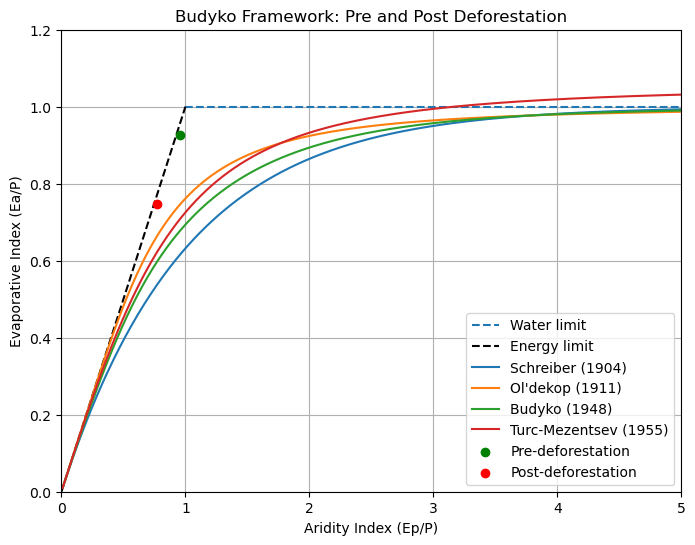

In [28]:
#plot the pre and post deforestation budyko points
plt.figure(figsize=(8,6))
plt.xlim(0, 5)
plt.ylim(0, 1.2)

phi = np.linspace(0.01, 5, 500)
EaP_schreiber = 1 - np.exp(-phi)
EaP_oldekop = phi * np.tanh(1 / phi)
EaP_budyko = np.sqrt(phi * np.tanh(1/phi) * (1 - np.exp(-phi)))
EaP_turc = 1 / np.sqrt(0.9 + (1/phi)**2)

# Water limit
plt.hlines(1, 1, 5, linestyles='--', label='Water limit')

# Energy limit
phi_energy = np.linspace(0, 1, 200)
plt.plot(phi_energy, phi_energy, 'k--', label='Energy limit')

# Analytical curves
plt.plot(phi, EaP_schreiber, label='Schreiber (1904)')
plt.plot(phi, EaP_oldekop, label='Ol\'dekop (1911)')
plt.plot(phi, EaP_budyko, label='Budyko (1948)')
plt.plot(phi, EaP_turc, label='Turc-Mezentsev (1955)')

# Pre and post deforestation points
plt.scatter(AI_pre, EI_pre, color='green', label='Pre-deforestation', zorder=5)
plt.scatter(AI_post, EI_post, color='red', label='Post-deforestation', zorder=5)

plt.xlabel("Aridity Index (Ep/P)")
plt.ylabel("Evaporative Index (Ea/P)")
plt.title("Budyko Framework: Pre and Post Deforestation")
plt.legend()
plt.grid(True)


import os
os.makedirs("Figures", exist_ok=True)

plt.savefig("Budyko_pre_post_deforestation.png", dpi=300, bbox_inches="tight")

plt.show()

In [29]:
c_pre_deforestation = c_pre_deforestation.rename(columns={
    "ERA5_Precipitation": "P",
    "ERA5_Evaporation": "EP"
})

c_post_deforestation = c_post_deforestation.rename(columns={
    "ERA5_Precipitation": "P",
    "ERA5_Evaporation": "EP"
})


,S,P,Ei,Pe,EP
time,,,,,
2014-01-01,0.0,0.000896,0.000896,0.000000,3.427859
2014-01-02,0.0,0.159864,0.159864,0.000000,2.922648
2014-01-03,0.0,0.024806,0.024806,0.000000,3.175775
2014-01-04,0.0,1.136705,1.136705,0.000000,3.261918
2014-01-05,0.0,0.313786,0.313786,0.000000,3.387740
2014-01-06,0.0,1.481937,1.481937,0.000000,3.174365
2014-01-07,0.0,4.968648,2.500000,2.468648,3.016709
2014-01-08,0.0,1.126547,1.126547,0.000000,1.783387
2014-01-09,0.0,0.442063,0.442063,0.000000,1.824233


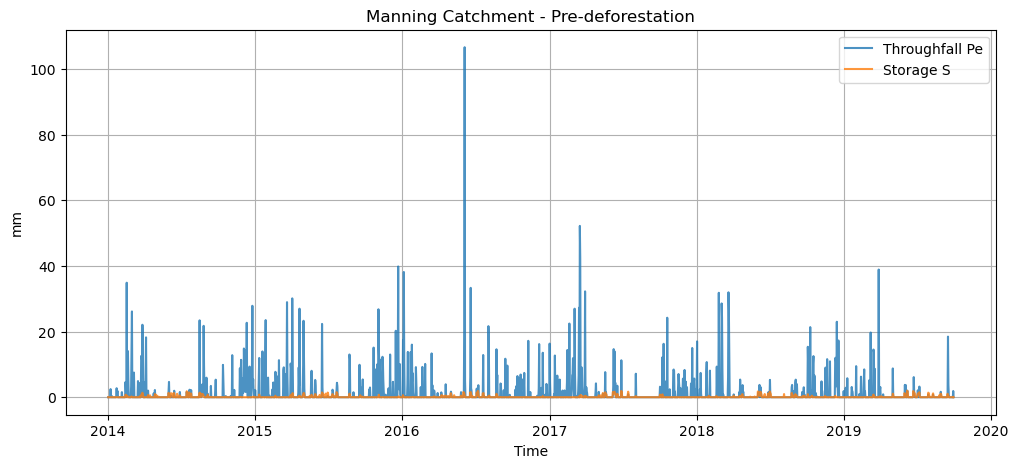

In [30]:
#interception storage

Smax = 2.5  # mm

S = np.zeros(len(c_pre_deforestation["P mm/d"]))
Pe = np.zeros(len(c_pre_deforestation["P mm/d"]))
Ei = np.zeros(len(c_pre_deforestation["P mm/d"]))

P = c_pre_deforestation["P mm/d"].values
EP = c_pre_deforestation["EP mm/d"].values

for i in range(len(P)):
    # opslag aan begin
    if i == 0:
        S_temp = 0 + P[i]   # Si(0)=0
    else:
        S_temp = S[i-1] + P[i]

    # overflow -> Pe
    if S_temp > Smax:
        Pe[i] = S_temp - Smax
        S_temp = Smax
    else:
        Pe[i] = 0.0

    # evaporatie, kan nooit groter zijn dan opslag
    Ei[i] = min(S_temp, EP[i])

    # eindopslag
    S[i] = S_temp - Ei[i]

df_pre = pd.DataFrame(index=c_pre_deforestation.index)
df_pre["S"] = S
df_pre["P"] = P
df_pre["Ei"] = Ei
df_pre["Pe"] = Pe
df_pre["EP"] = EP

display(df_pre.head(10))
plt.figure(figsize=(12,5))
plt.plot(df_pre.index, df_pre["Pe"], label="Throughfall Pe", alpha=0.8)
plt.plot(df_pre.index, df_pre["S"], label="Storage S", alpha=0.8)
# plt.plot(df_pre.index, df_pre["Ei"], label="Interception evaporation Ei", alpha=0.8)
# plt.plot(df_pre.index, df_pre["P"], label="Precipitation P", alpha=0.4)

plt.title("Manning Catchment - Pre-deforestation")
plt.xlabel("Time")
plt.ylabel("mm")
plt.legend()
plt.grid(True)

,S,P,Ei,Pe,EP
time,,,,,
2020-03-01,0.000000,0.115157,0.115157,0.000000,3.753968
2020-03-02,0.000000,1.063607,1.063607,0.000000,4.185690
2020-03-03,0.000000,3.922860,2.500000,1.422860,2.532448
2020-03-04,0.000000,3.019995,2.500000,0.519995,2.742730
2020-03-05,0.199914,10.753945,2.300086,8.253945,2.300086
2020-03-06,0.000000,8.411995,2.500000,6.111908,3.808003
2020-03-07,0.000000,3.949287,2.500000,1.449287,3.404269
2020-03-08,0.000000,3.503742,2.500000,1.003742,2.835332
2020-03-09,0.644087,4.412354,1.855913,1.912354,1.855913


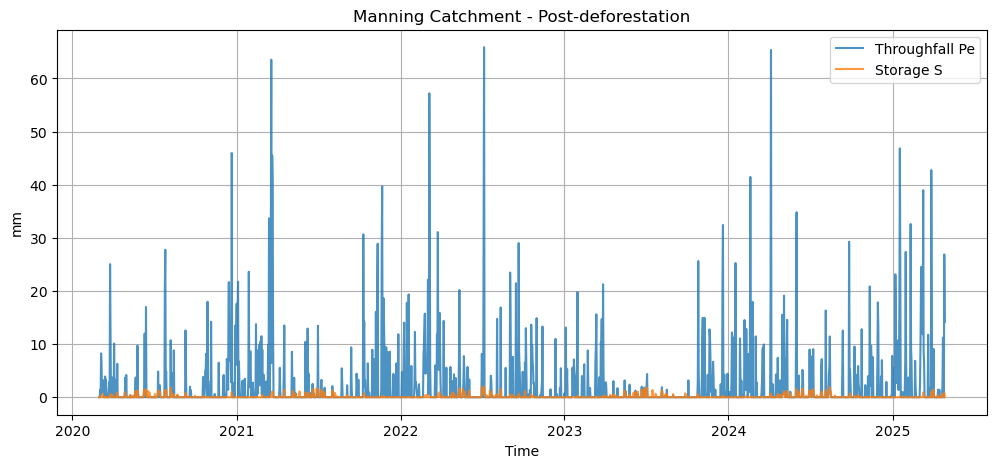

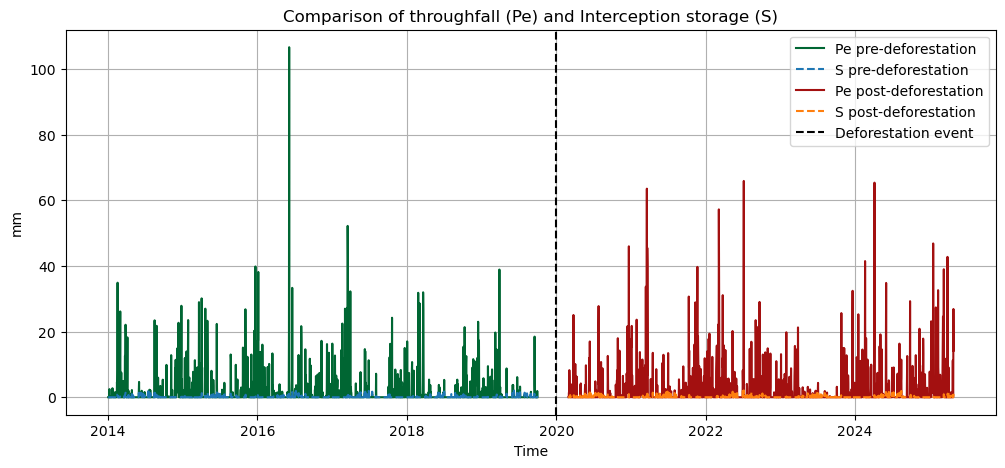

In [40]:
S = np.zeros(len(c_post_deforestation["P mm/d"]))
Pe = np.zeros(len(c_post_deforestation["P mm/d"]))
Ei = np.zeros(len(c_post_deforestation["P mm/d"]))

P = c_post_deforestation["P mm/d"].values
EP = c_post_deforestation["EP mm/d"].values

for i in range(len(P)):
    # opslag aan begin
    if i == 0:
        S_temp = 0 + P[i]   # Si(0)=0
    else:
        S_temp = S[i-1] + P[i]

    # overflow -> Pe
    if S_temp > Smax:
        Pe[i] = S_temp - Smax
        S_temp = Smax
    else:
        Pe[i] = 0.0

    # evaporatie, kan nooit groter zijn dan opslag
    Ei[i] = min(S_temp, EP[i])

    # eindopslag
    S[i] = S_temp - Ei[i]

df_post = pd.DataFrame(index=c_post_deforestation.index)
df_post["S"] = S
df_post["P"] = P
df_post["Ei"] = Ei
df_post["Pe"] = Pe
df_post["EP"] = EP

display(df_post.head(10))

plt.figure(figsize=(12,5))
plt.plot(df_post.index, df_post["Pe"], label="Throughfall Pe", alpha=0.8)
plt.plot(df_post.index, df_post["S"], label="Storage S", alpha=0.8)
# plt.plot(df_post.index, df_post["Ei"], label="Interception evaporation Ei", alpha=0.8)
# plt.plot(df_post.index, df_post["P"], label="Precipitation P", alpha=0.4)

plt.title("Manning Catchment - Post-deforestation")
plt.xlabel("Time")
plt.ylabel("mm")
plt.legend()
plt.grid(True)
plt.show()

# Define the transition dates
pre_end = "2019-12-31"
post_start = "2020-01-01"

# Combined plot for pre and post deforestation: throughfall (Pe) and storage (S)
plt.figure(figsize=(12,5))
plt.plot(df_pre.index, df_pre["Pe"], label="Pe pre-deforestation", color='#006633')
plt.plot(df_pre.index, df_pre["S"], label="S pre-deforestation", linestyle='--')
plt.plot(df_post.index, df_post["Pe"], label="Pe post-deforestation", color='#a31010')
plt.plot(df_post.index, df_post["S"], label="S post-deforestation", linestyle='--')

plt.axvline(pd.Timestamp(pre_end), linestyle='--', color='black', label='Deforestation event')

plt.title("Comparison of throughfall (Pe) and Interception storage (S)")
plt.xlabel("Time")
plt.ylabel("mm")
plt.legend()
plt.grid(True)
plt.show()

In [39]:
#average throughfall and storage pre and post deforestation
Pe_pre_avg = df_pre["Pe"].mean()
S_pre_avg = df_pre["S"].mean()

Pe_post_avg = df_post["Pe"].mean()
S_post_avg = df_post["S"].mean()

print(f"Average throughfall (Pe) pre-deforestation: {Pe_pre_avg:.2f} mm")
print(f"Average storage (S) pre-deforestation: {S_pre_avg:.2f} mm")
print(f"Average throughfall (Pe) post-deforestation: {Pe_post_avg:.2f} mm")
print(f"Average storage (S) post-deforestation: {S_post_avg:.2f} mm")

Average throughfall (Pe) pre-deforestation: 1.59 mm
Average storage (S) pre-deforestation: 0.10 mm
Average throughfall (Pe) post-deforestation: 2.31 mm
Average storage (S) post-deforestation: 0.11 mm


In [43]:
summary = pd.DataFrame({
    "Pre-deforestation": [
        df_pre["P"].mean(),
        df_pre["Pe"].mean(),
        df_pre["Ei"].mean(),
        df_pre["S"].mean(),
        df_pre["Pe"].mean() / df_pre["P"].mean()
    ],
    "Post-deforestation": [
        df_post["P"].mean(),
        df_post["Pe"].mean(),
        df_post["Ei"].mean(),
        df_post["S"].mean(),
        df_post["Pe"].mean() / df_post["P"].mean()
    ]
}, index=[
    "Mean P (mm/d)",
    "Mean Pe (mm/d)",
    "Mean Ei (mm/d)",
    "Mean S (mm)",
    "Pe/P ratio"
])

display(summary)


,Pre-deforestation,Post-deforestation
Mean P (mm/d),2.474720,3.331637
Mean Pe (mm/d),1.592854,2.314083
Mean Ei (mm/d),0.881866,1.017554
Mean S (mm),0.099852,0.105435
Pe/P ratio,0.643650,0.694578


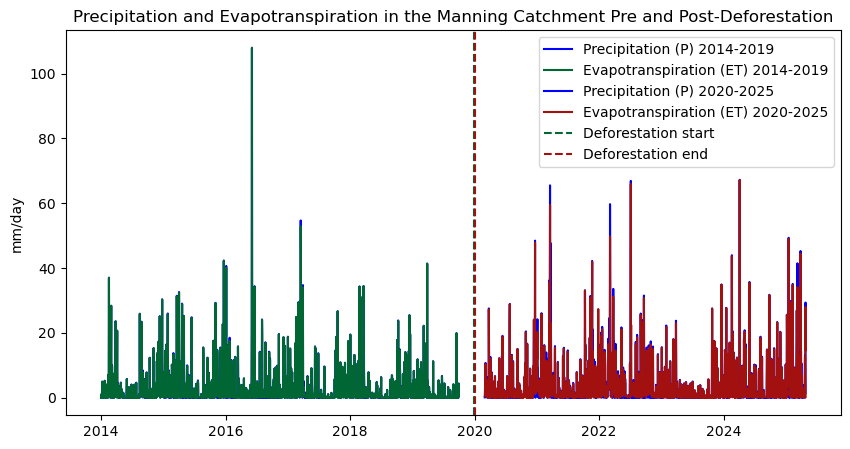

In [44]:
# Filter data to 2014-2025
data["ET mm/d"] = data["ET mm/d"].abs()
data_2014_2025 = data.loc["2014-01-01":"2025-12-31"]

# Split into pre and post 2019/2020
pre_2014_2019 = data_2014_2025.loc["2014-01-01":"2019-10-01"]
post_2020_2025 = data_2014_2025.loc["2020-03-01":"2025-12-31"]

plt.figure(figsize=(10,5))

# Plot pre-deforestation (2014-2019)
plt.plot(pre_2014_2019.index, pre_2014_2019["P mm/d"], label="Precipitation (P) 2014-2019", color="blue")
plt.plot(pre_2014_2019.index, pre_2014_2019["ET mm/d"], label="Evapotranspiration (ET) 2014-2019", color="#006633")

# Plot post-deforestation (2020-2025)
data["ET mm/d"] = data["ET mm/d"].abs()
plt.plot(post_2020_2025.index, post_2020_2025["P mm/d"], label="Precipitation (P) 2020-2025", color="blue")
plt.plot(post_2020_2025.index, post_2020_2025["ET mm/d"], label="Evapotranspiration (ET) 2020-2025", color="#a31010")
plt.axvline(pd.Timestamp(pre_end), linestyle='--', color='#006633', label='Deforestation start')
plt.axvline(pd.Timestamp(post_start), linestyle='--', color='#a31010', label='Deforestation end')

plt.ylabel("mm/day")
plt.title("Precipitation and Evapotranspiration in the Manning Catchment Pre and Post-Deforestation")
plt.legend()
plt.show()

In [45]:
#average precipitation and evapotranspiration pre and post deforestation
P_pre_avg = pre_2014_2019["P mm/d"].mean()
ET_pre_avg = pre_2014_2019["ET mm/d"].mean()
P_post_avg = post_2020_2025["P mm/d"].mean()
ET_post_avg = post_2020_2025["ET mm/d"].mean()

print(f"Average Precipitation (P) pre-deforestation: {P_pre_avg:.2f} mm/day")
print(f"Average Evapotranspiration (ET) pre-deforestation: {ET_pre_avg:.2f} mm/day")
print(f"Average Precipitation (P) post-deforestation: {P_post_avg:.2f} mm/day")
print(f"Average Evapotranspiration (ET) post-deforestation: {ET_post_avg:.2f} mm/day")

Average Precipitation (P) pre-deforestation: 2.47 mm/day
Average Evapotranspiration (ET) pre-deforestation: 2.44 mm/day
Average Precipitation (P) post-deforestation: 3.33 mm/day
Average Evapotranspiration (ET) post-deforestation: 3.30 mm/day


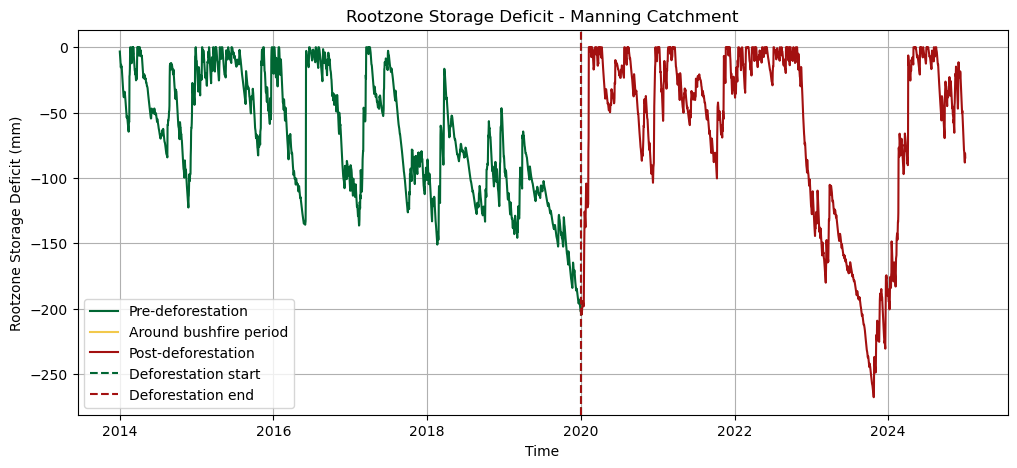

In [46]:

full_period = data.loc["2014-01-01":"2025-01-01"].copy()
ET_LT_full = full_period["P mm/d"].mean() - full_period["Q mm/d"].mean()
ET_full = full_period["EP mm/d"] * (ET_LT_full / full_period["EP mm/d"].mean())

SD_full = np.zeros(len(full_period))
for i in range(len(SD_full)):
    if i == 0:
        SD_full[i] = np.minimum(
            0,
            full_period["P mm/d"].iloc[i] - ET_full.iloc[i])
    else:
        SD_full[i] = np.minimum(
            0,
            SD_full[i-1] + full_period["P mm/d"].iloc[i] - ET_full.iloc[i])
df2_full = pd.DataFrame(index=full_period.index)
df2_full["ET_full"] = ET_full
df2_full["SD_full"] = SD_full

pre_mask = (df2_full.index >= pd.Timestamp("2014-01-01")) & (df2_full.index <= pd.Timestamp(pre_end))
mid_mask = (df2_full.index > pd.Timestamp(pre_end)) & (df2_full.index < pd.Timestamp(post_start))
post_mask = (df2_full.index >= pd.Timestamp(post_start)) & (df2_full.index <= pd.Timestamp("2025-01-01"))
plt.figure(figsize=(12,5))

plt.plot(df2_full.index[pre_mask], df2_full.loc[pre_mask, "SD_full"],label="Pre-deforestation", color="#006633")

plt.plot(df2_full.index[mid_mask], df2_full.loc[mid_mask, "SD_full"],label="Around bushfire period", color="#f2c94c")

plt.plot(df2_full.index[post_mask], df2_full.loc[post_mask, "SD_full"],label="Post-deforestation", color="#a31010")

plt.axvline(pd.Timestamp(pre_end), linestyle='--', color='#006633', label='Deforestation start')
plt.axvline(pd.Timestamp(post_start), linestyle='--', color='#a31010', label='Deforestation end')

plt.title("Rootzone Storage Deficit - Manning Catchment")
plt.ylabel("Rootzone Storage Deficit (mm)")
plt.xlabel("Time")
plt.legend()
plt.grid(True)
plt.show()

In [47]:
#average rootzone storage deficit pre and post deforestation
SD_pre_avg = df2_full.loc[pre_mask, "SD_full"].mean()
SD_post_avg = df2_full.loc[post_mask, "SD_full"].mean()
print(f"Average Rootzone Storage Deficit pre-deforestation: {SD_pre_avg:.2f} mm")
print(f"Average Rootzone Storage Deficit post-deforestation: {SD_post_avg:.2f} mm")


Average Rootzone Storage Deficit pre-deforestation: -67.03 mm
Average Rootzone Storage Deficit post-deforestation: -64.21 mm


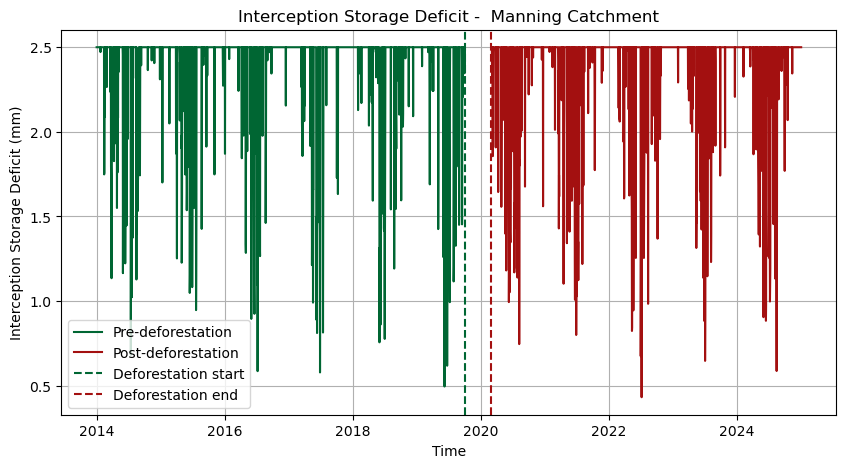

In [48]:
plt.figure(figsize=(10,5))
Si_max = 2.5  # mm
pre_start = "2014-01-01"
pre_end   = "2019-10-01"
post_start = "2020-03-01"
post_end   = "2025-01-01"

df_pre_sel = df_pre.loc[pre_start:pre_end]
df_post_sel = df_post.loc[post_start:post_end]
# plot deficit = Smax - S
plt.plot(df_pre_sel.index, Si_max - df_pre_sel["S"],
         label="Pre-deforestation", color="#006633")

plt.plot(df_post_sel.index, Si_max - df_post_sel["S"],
         label="Post-deforestation", color="#a31010")

plt.axvline(pd.Timestamp(pre_end), linestyle='--', color='#006633', label='Deforestation start')
plt.axvline(pd.Timestamp(post_start), linestyle='--', color='#a31010', label='Deforestation end')

plt.ylabel("Interception Storage Deficit (mm)")
plt.xlabel("Time")
plt.title("Interception Storage Deficit -  Manning Catchment")

plt.legend()
plt.grid(True)
plt.show()

In [49]:
#average interception storage deficit pre and post deforestation
df_pre_sel["Interception Storage Deficit"] = Si_max - df_pre_sel["S"]
df_post_sel["Interception Storage Deficit"] = Si_max - df_post_sel["S"]
ISD_pre_avg = df_pre_sel["Interception Storage Deficit"].mean()
ISD_post_avg = df_post_sel["Interception Storage Deficit"].mean()

print(f"Average Interception Storage Deficit pre-deforestation: {ISD_pre_avg:.2f} mm")
print(f"Average Interception Storage Deficit post-deforestation: {ISD_post_avg:.2f} mm")


Average Interception Storage Deficit pre-deforestation: 2.40 mm
Average Interception Storage Deficit post-deforestation: 2.39 mm


C:\Users\madis\AppData\Local\Temp\ipykernel_9688\2507695929.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pre_sel["Interception Storage Deficit"] = Si_max - df_pre_sel["S"]
C:\Users\madis\AppData\Local\Temp\ipykernel_9688\2507695929.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_post_sel["Interception Storage Deficit"] = Si_max - df_post_sel["S"]
